In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel("Untitled spreadsheet.xlsx", header=1)
print(df.head())

          ID   Source  Severity          Start_Time            End_Time  \
0   A-524489  Source2         3 2022-08-28 11:40:28 2022-08-28 12:25:08   
1   A-711298  Source2         3 2022-02-14 06:04:45 2022-02-14 06:33:46   
2  A-3654829  Source1         2 2023-03-26 14:13:00 2023-03-26 16:29:24   
3  A-3705406  Source1         2 2022-01-03 14:26:00 2022-01-03 16:40:02   
4  A-3787111  Source1         2 2022-09-16 08:58:00 2022-09-16 10:17:51   

   Start_Lat   Start_Lng    End_Lat     End_Lng  Distance_mi_  ... Roundabout  \
0  40.250141  -75.346863        NaN         NaN        21.900  ...      False   
1  33.177776 -111.887955        NaN         NaN         0.000  ...      False   
2  40.857498  -77.056473  40.858029  -77.056837         0.041  ...      False   
3  28.811420  -82.088588  28.856270  -82.089868         3.100  ...      False   
4  34.285566 -117.992945  34.297387 -118.002774         0.991  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop S

In [2]:
df.info()

df.shape

df.columns

df.isnull().sum()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID                     500 non-null    object        
 1   Source                 500 non-null    object        
 2   Severity               500 non-null    int64         
 3   Start_Time             500 non-null    datetime64[ns]
 4   End_Time               500 non-null    datetime64[ns]
 5   Start_Lat              500 non-null    float64       
 6   Start_Lng              500 non-null    float64       
 7   End_Lat                439 non-null    float64       
 8   End_Lng                439 non-null    float64       
 9   Distance_mi_           500 non-null    float64       
 10  Description            500 non-null    object        
 11  Street                 492 non-null    object        
 12  City                   497 non-null    object        
 13  Count

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance_mi_,Weather_Timestamp,Temperature_F_,Wind_Chill_F_,Humidity_%_,Pressure_in_,Visibility_mi_,Wind_Speed_mph_,Precipitation_in_
count,500.000000,500,500,500.000000,500.000000,439.000000,439.000000,500.000000,420,417.000000,415.000000,416.000000,420.000000,413.000000,417.000000,412.000000
mean,2.234000,2022-02-19 00:51:09.024000,2022-02-19 04:15:30.060000,36.837495,-89.530945,37.009054,-89.807623,1.254702,2022-02-26 09:57:28,56.514628,54.075181,69.432692,29.134833,8.809927,8.056355,0.011141
min,1.000000,2017-01-10 09:42:10,2017-01-10 15:42:10,25.884497,-124.285954,25.925805,-124.286122,0.000000,2017-01-10 09:48:00,-6.000000,-30.000000,10.000000,21.140000,0.250000,0.000000,0.000000
25%,2.000000,2021-10-10 10:08:19.500000,2021-10-10 11:28:27.249999872,33.499978,-94.483921,33.679221,-94.750416,0.089250,2021-10-20 21:54:30,41.000000,34.000000,54.000000,28.957500,10.000000,5.000000,0.000000
50%,2.000000,2022-03-11 00:58:15,2022-03-11 01:57:00,38.316847,-85.084852,38.506897,-86.194621,0.407500,2022-03-18 09:54:00,60.000000,60.000000,71.500000,29.530000,10.000000,7.000000,0.000000
75%,2.000000,2022-08-06 07:50:21.500000,2022-08-06 08:53:49.750000128,40.132958,-80.233401,40.175571,-80.282271,1.416500,2022-08-15 07:10:15,75.000000,74.500000,87.000000,29.940000,10.000000,10.000000,0.000000
max,4.000000,2023-03-29 06:38:00,2023-03-29 09:08:57,48.836539,-72.016221,48.851039,-72.015155,21.900000,2023-03-29 06:40:00,91.000000,91.000000,100.000000,30.410000,15.000000,33.000000,1.590000
std,0.622913,NaN,NaN,5.198768,13.090477,5.322085,12.965404,2.230269,NaN,21.933396,25.529782,20.861108,1.337259,2.648538,6.269670,0.086249


In [3]:
df.duplicated().sum()

np.int64(0)

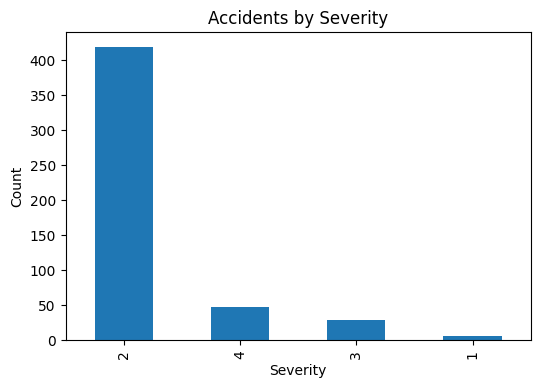

In [4]:
df["Severity"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Accidents by Severity")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

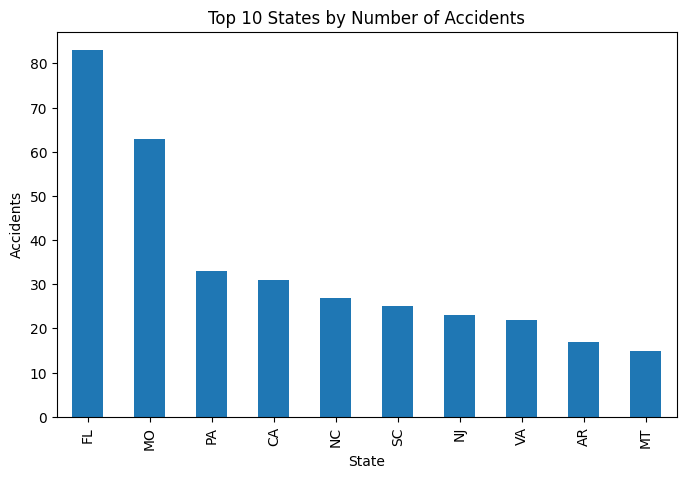

In [5]:
top_states = df["State"].value_counts().head(10)

top_states.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Top 10 States by Number of Accidents")
plt.xlabel("State")
plt.ylabel("Accidents")
plt.show()

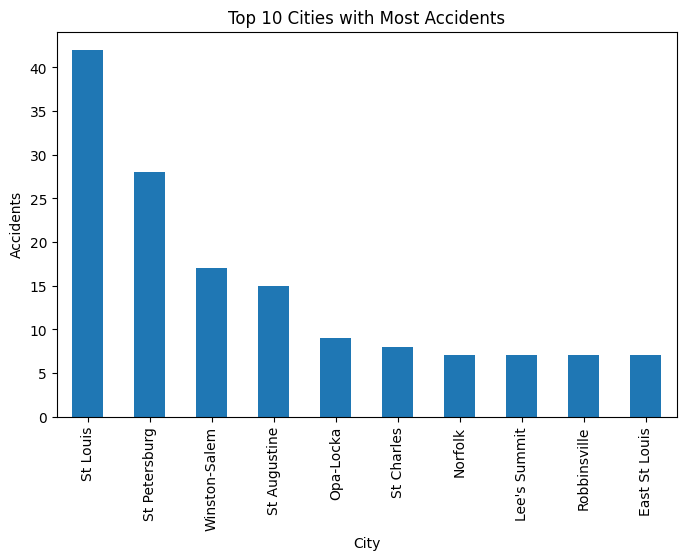

In [6]:
top_cities = df["City"].value_counts().head(10)

top_cities.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Top 10 Cities with Most Accidents")
plt.xlabel("City")
plt.ylabel("Accidents")
plt.show()

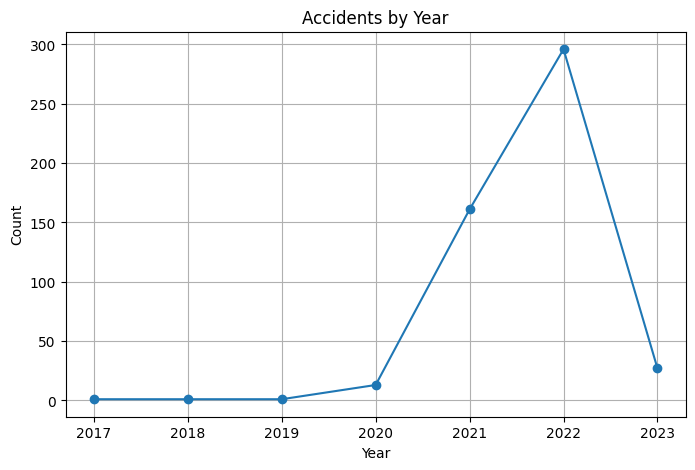

In [7]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"])

df["Year"] = df["Start_Time"].dt.year

df["Year"].value_counts().sort_index().plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Accidents by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.show()

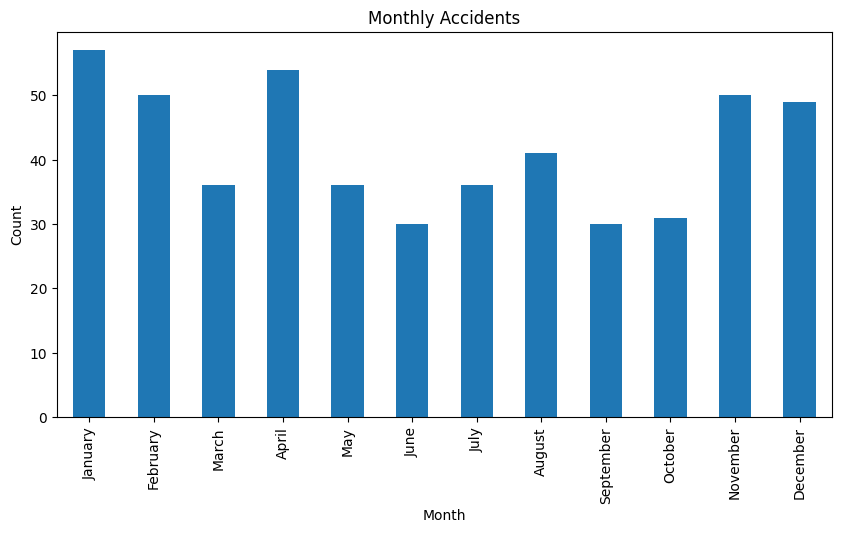

In [8]:
df["Month"] = df["Start_Time"].dt.month_name()

order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

df["Month"] = pd.Categorical(df["Month"], categories=order, ordered=True)

df["Month"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Monthly Accidents")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

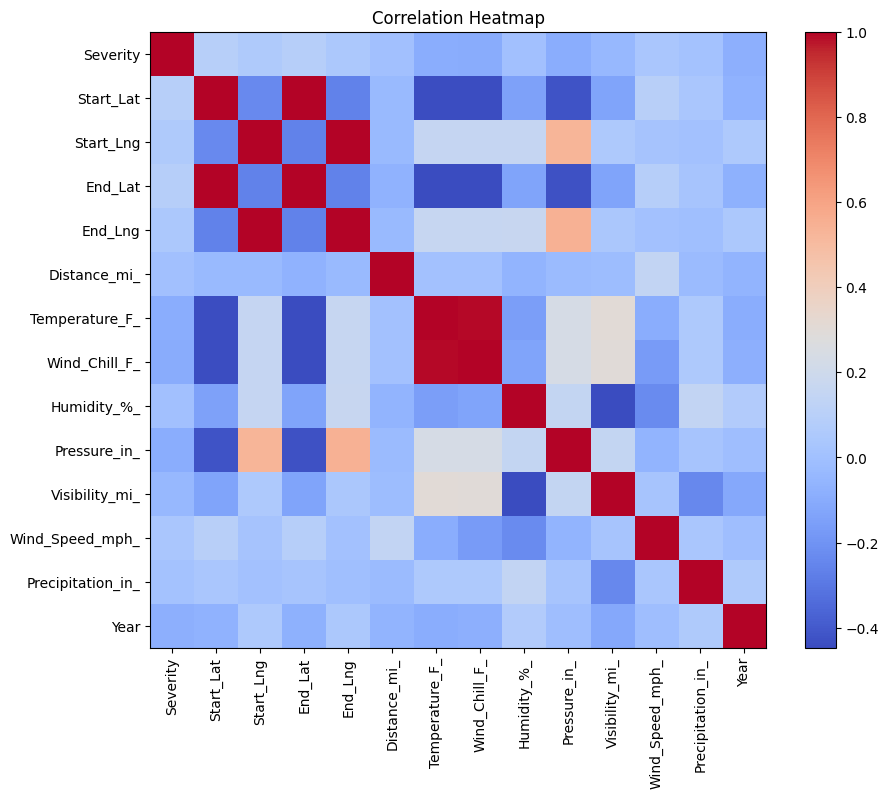

In [9]:
numeric = df.select_dtypes(include="number")

corr = numeric.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

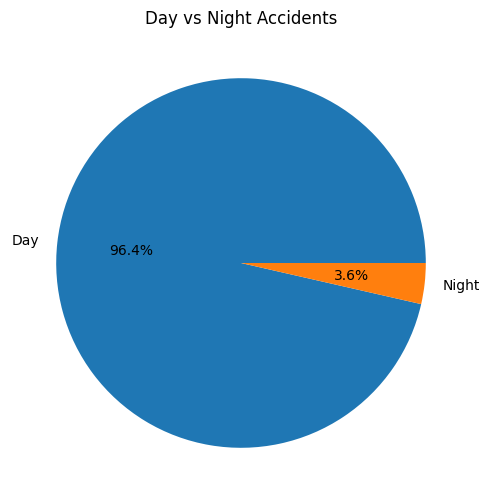

In [10]:
df["Sunrise_Sunset"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Day vs Night Accidents")
plt.show()

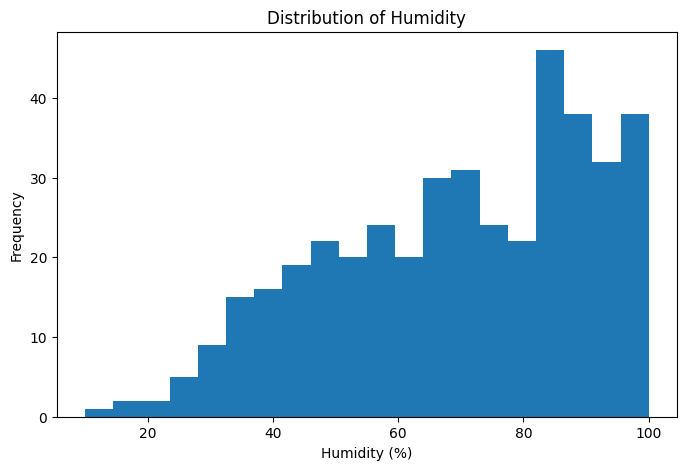

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df["Humidity_%_"].dropna(), bins=20)

plt.title("Distribution of Humidity")
plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")

plt.show()

In [13]:
import pandas as pd
import plotly.express as px
df["Start_Time"] = pd.to_datetime(df["Start_Time"])
df["Year"] = df["Start_Time"].dt.year
ribbon_data = (
    df.groupby(["Year", "Severity"])
      .size()
      .reset_index(name="Accidents")
)

fig = px.area(
    ribbon_data,
    x="Year",
    y="Accidents",
    color="Severity",
    title="Accidents by Severity Over the Years"
)

fig.show()